# Wildfire Risk — Report Visualisations
Kazakhstan FWI workflow — report-ready figures.

**Prerequisites**
1. Run `wildfire_FWI_hazard_KAZ` and `wildfire_FWI_risk_KAZ` notebooks first.
2. Add these two lines at the end of the risk notebook:
   ```python
   risk_hist.to_netcdf(data_dir / 'risk_hist.nc')
   risk_fut.to_netcdf(data_dir / 'risk_fut.nc')
   ```

In [28]:
import pathlib
from math import pi

import numpy as np
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Configuration

In [29]:
region_id          = 'KAZ_EKO'
oblast_en          = 'East Kazakhstan Region'
MODELS             = ['GFDL-ESM4']
HIST_START, HIST_END     = 1985, 2014
FUTURE_SCENARIO          = 'ssp370'
FUTURE_START, FUTURE_END = 2041, 2050
FWI_THRESHOLD      = 30.0
BBOX_BUFFER        = 0.5

DANGER_BREAKS = [0, 11.2, 21.3, 38.0, 50.0, 70.0, 200]
DANGER_LABELS = ['Low', 'Moderate', 'High', 'Very High', 'Extreme', 'Very Extreme']
DANGER_COLORS = ['#1a9641', '#a6d96a', '#fdae61', '#f46d43', '#d73027', '#a50026']

KAZ_SHP = pathlib.Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  # <-- update to your local shapefile path

work_dir    = pathlib.Path('.')
data_dir    = work_dir / 'data'
results_dir = work_dir / 'results'
cache_dir   = data_dir / 'isimip_clipped'
results_dir.mkdir(exist_ok=True)

## Load data

In [30]:
kaz_gdf       = gpd.read_file(KAZ_SHP)
eko_gdf       = kaz_gdf[kaz_gdf['oblast_en'] == oblast_en].copy()
eko_dissolved = eko_gdf.dissolve().reset_index(drop=True)
minx, miny, maxx, maxy = eko_dissolved.total_bounds
LON_MIN = minx - BBOX_BUFFER;  LON_MAX = maxx + BBOX_BUFFER
LAT_MIN = miny - BBOX_BUFFER;  LAT_MAX = maxy + BBOX_BUFFER


def load_fwi_stack(scenario, y0, y1):
    arrs = []
    for m in MODELS:
        p = cache_dir / f'fwi_stats_{m.lower()}_{scenario}_{y0}_{y1}.nc'
        if p.exists():
            arrs.append(xr.open_dataset(p).assign_coords(model=m).expand_dims('model'))
    if not arrs:
        raise FileNotFoundError(f'No cached fwi_stats for {scenario} {y0}–{y1}')
    return xr.concat(arrs, dim='model')


hist_ds = load_fwi_stack('historical',    HIST_START,   HIST_END)
fut_ds  = load_fwi_stack(FUTURE_SCENARIO, FUTURE_START, FUTURE_END)

hist_seas  = hist_ds['seasonal_mean']   # (model, year, lat, lon)
fut_seas   = fut_ds['seasonal_mean']
hist_fday  = hist_ds['fire_days']
fut_fday   = fut_ds['fire_days']

lats = hist_seas.lat.values
lons = hist_seas.lon.values
lon2d, lat2d = np.meshgrid(lons, lats)

hist_mean      = hist_seas.mean(dim=['model', 'year']).values
fut_mean       = fut_seas.mean(dim=['model', 'year']).values
delta_fwi      = fut_mean - hist_mean
hist_fday_mean = hist_fday.mean(dim=['model', 'year']).values
fut_fday_mean  = fut_fday.mean(dim=['model', 'year']).values
delta_fday     = fut_fday_mean - hist_fday_mean

# Optional: needed for Figures 4 and 6
risk_hist = xr.open_dataset(data_dir / 'risk_hist.nc') if (data_dir / 'risk_hist.nc').exists() else None
risk_fut  = xr.open_dataset(data_dir / 'risk_fut.nc')  if (data_dir / 'risk_fut.nc').exists() else None
if risk_hist is None:
    print('risk_hist.nc not found — Figures 4 and 6 will be skipped.')
    print('Add risk_hist.to_netcdf(data_dir / "risk_hist.nc") to the end of the risk notebook.')


def add_kaz_boundary(ax):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888')
    eko_dissolved.boundary.plot(ax=ax, transform=ccrs.PlateCarree(),
                                color='black', linewidth=1.5)


def class_fracs(arr_flat, breaks):
    v = arr_flat[~np.isnan(arr_flat)]
    return [np.mean((v >= breaks[i]) & (v < breaks[i+1])) for i in range(len(breaks)-1)]

## Figure 1 — Seasonal FWI change per grid cell

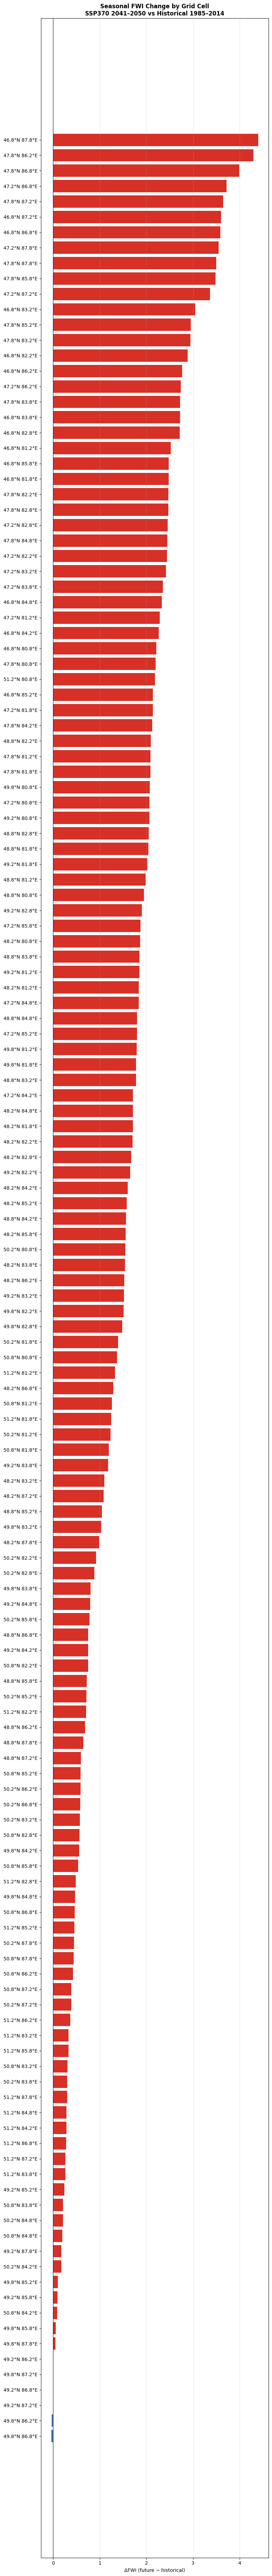

In [31]:
valid  = ~np.isnan(delta_fwi)
labels = [f'{la:.1f}°N {lo:.1f}°E' for la, lo in zip(lat2d[valid], lon2d[valid])]
vals   = delta_fwi[valid]
order  = np.argsort(vals)

fig, ax = plt.subplots(figsize=(8, max(3, len(labels) * 0.5)))
ax.barh([labels[i] for i in order], vals[order],
        color=['#d73027' if v > 0 else '#4575b4' for v in vals[order]])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ΔFWI (future − historical)')
ax.set_title(f'Seasonal FWI Change by Grid Cell\n'
             f'{FUTURE_SCENARIO.upper()} {FUTURE_START}–{FUTURE_END} vs '
             f'Historical {HIST_START}–{HIST_END}', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_report_fwi_delta_bars.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## Figure 2 — Fire season length change map

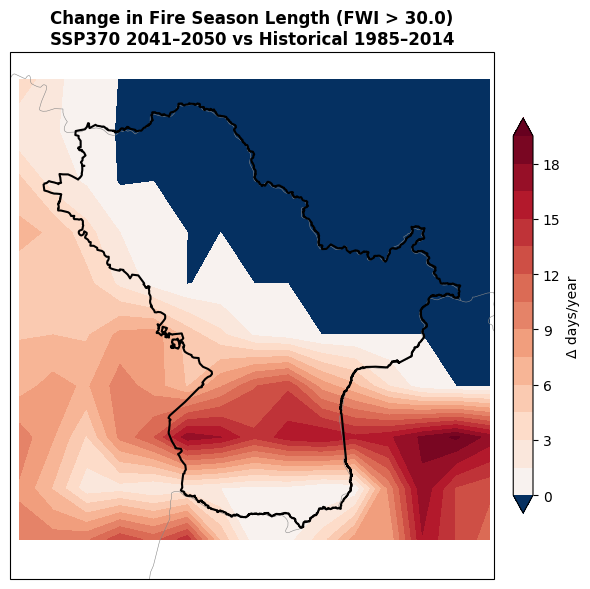

In [32]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
add_kaz_boundary(ax)
vmax = max(np.nanmax(np.abs(delta_fday)), 0.1)
cf = ax.contourf(lon2d, lat2d, delta_fday, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=15, extend='both')
plt.colorbar(cf, ax=ax, shrink=0.75, pad=0.02, label='Δ days/year')
ax.set_title(f'Change in Fire Season Length (FWI > {FWI_THRESHOLD})\n'
             f'{FUTURE_SCENARIO.upper()} {FUTURE_START}–{FUTURE_END} vs '
             f'Historical {HIST_START}–{HIST_END}', fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_report_firedays_delta_map.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## Figure 3 — FWI threshold exceedance

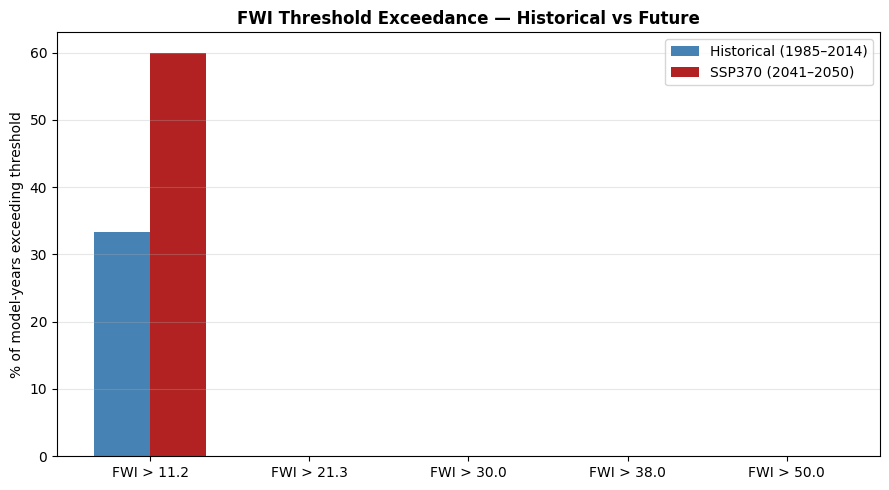

In [33]:
wts    = np.cos(np.deg2rad(hist_seas.lat))
h_flat = hist_seas.weighted(wts).mean(dim=['lat', 'lon']).values.ravel()
f_flat = fut_seas.weighted(wts).mean(dim=['lat', 'lon']).values.ravel()
h_flat = h_flat[~np.isnan(h_flat)]
f_flat = f_flat[~np.isnan(f_flat)]

thresholds = [11.2, 21.3, 30.0, 38.0, 50.0]
h_exc = [np.mean(h_flat > t) * 100 for t in thresholds]
f_exc = [np.mean(f_flat > t) * 100 for t in thresholds]

x, w = np.arange(len(thresholds)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, h_exc, w, label=f'Historical ({HIST_START}–{HIST_END})',         color='steelblue')
ax.bar(x + w/2, f_exc, w, label=f'{FUTURE_SCENARIO.upper()} ({FUTURE_START}–{FUTURE_END})', color='firebrick')
ax.set_xticks(x); ax.set_xticklabels([f'FWI > {t}' for t in thresholds])
ax.set_ylabel('% of model-years exceeding threshold')
ax.set_title('FWI Threshold Exceedance — Historical vs Future', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_report_exceedance.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## Figure 4 — Risk component heatmap (requires risk_hist.nc)

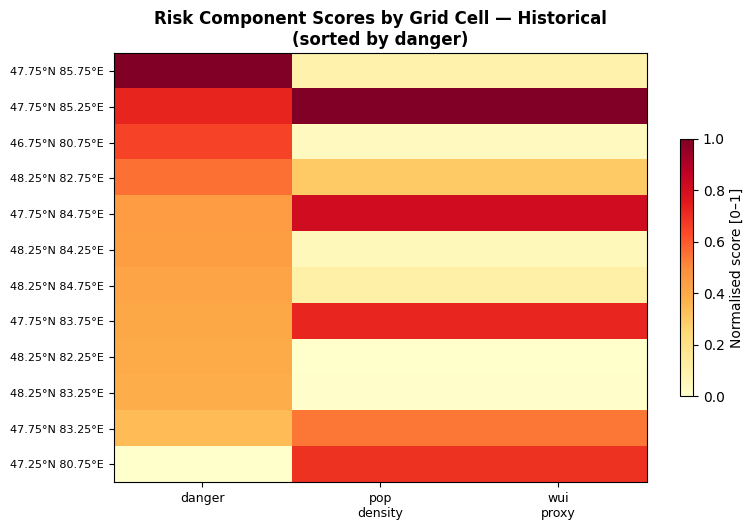

In [34]:
if risk_hist is not None:
    risk_vars = [v for v in ['danger', 'pop_density', 'wui_proxy', 'prot_area', 'biomass']
                 if v in risk_hist]
    df   = risk_hist[risk_vars].to_dataframe().reset_index().dropna(subset=risk_vars)
    df_n = df[risk_vars].copy()
    for c in risk_vars:
        mn, mx = df_n[c].min(), df_n[c].max()
        df_n[c] = (df_n[c] - mn) / (mx - mn) if mx > mn else 0.0
    df_n.index = [f'{r.lat:.2f}°N {r.lon:.2f}°E' for _, r in df[['lat', 'lon']].iterrows()]
    df_n = df_n.sort_values('danger', ascending=False)

    fig, ax = plt.subplots(figsize=(8, max(3, len(df_n) * 0.45)))
    im = ax.imshow(df_n.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(len(risk_vars)))
    ax.set_xticklabels([v.replace('_', '\n') for v in risk_vars], fontsize=9)
    ax.set_yticks(range(len(df_n))); ax.set_yticklabels(df_n.index, fontsize=8)
    plt.colorbar(im, ax=ax, label='Normalised score [0–1]', shrink=0.6)
    ax.set_title('Risk Component Scores by Grid Cell — Historical\n(sorted by danger)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(results_dir / f'{region_id}_report_risk_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
else:
    print('Skipping Figure 4 — risk_hist.nc not available.')

## Figure 5 — Scenario comparison strip

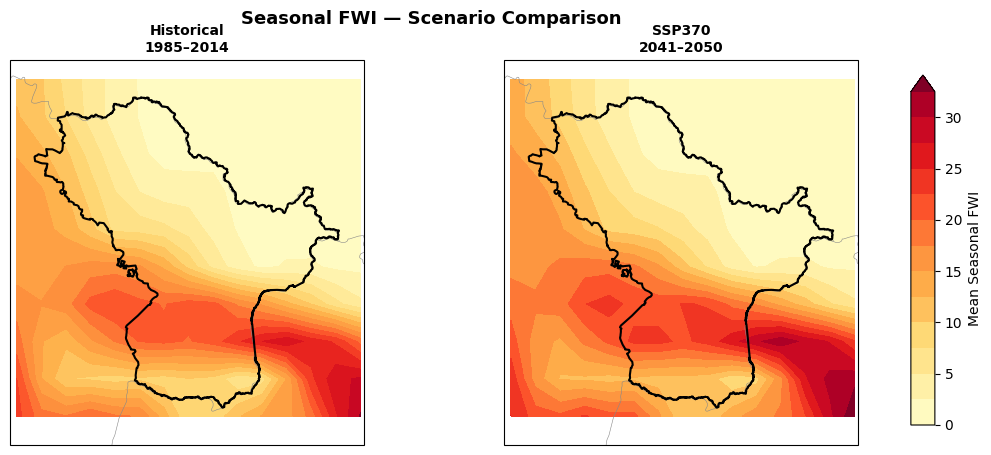

In [35]:
try:
    ssp126_ds   = load_fwi_stack('ssp126', FUTURE_START, FUTURE_END)
    ssp126_mean = ssp126_ds['seasonal_mean'].mean(dim=['model', 'year']).values
    panels = [
        ('Historical',            hist_mean,   f'{HIST_START}–{HIST_END}'),
        ('SSP1-2.6',              ssp126_mean, f'{FUTURE_START}–{FUTURE_END}'),
        (FUTURE_SCENARIO.upper(), fut_mean,    f'{FUTURE_START}–{FUTURE_END}'),
    ]
except FileNotFoundError:
    panels = [
        ('Historical',            hist_mean, f'{HIST_START}–{HIST_END}'),
        (FUTURE_SCENARIO.upper(), fut_mean,  f'{FUTURE_START}–{FUTURE_END}'),
    ]

vmax_p = np.nanmax([np.nanmax(m) for _, m, _ in panels])
fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})
if len(panels) == 2:
    axes = list(axes)
for ax, (lbl, data, period) in zip(axes, panels):
    add_kaz_boundary(ax)
    cf = ax.contourf(lon2d, lat2d, data, transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', vmin=0, vmax=vmax_p, levels=15, extend='max')
    ax.set_title(f'{lbl}\n{period}', fontweight='bold', fontsize=10)
fig.suptitle('Seasonal FWI — Scenario Comparison', fontsize=13, fontweight='bold')
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
fig.colorbar(cf, cax=cax, label='Mean Seasonal FWI')
plt.savefig(results_dir / f'{region_id}_report_scenario_strip.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## Figure 6 — Vulnerability radar chart (requires risk_hist.nc)

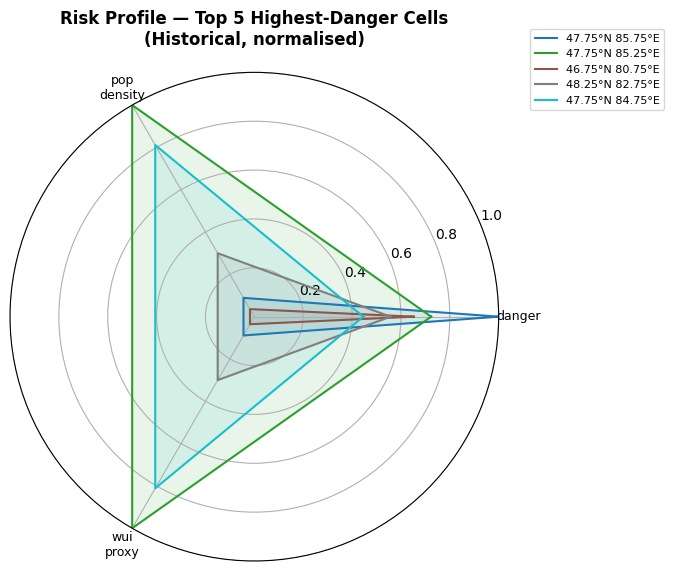

In [36]:
if risk_hist is not None:
    vuln_vars = [v for v in ['pop_density', 'wui_proxy', 'prot_area', 'biomass']
                 if v in risk_hist]
    if 'danger' in risk_hist and vuln_vars:
        cats = ['danger'] + vuln_vars
        df   = risk_hist[cats].to_dataframe().reset_index().dropna(subset=cats)
        for c in cats:
            mn, mx = df[c].min(), df[c].max()
            df[c] = (df[c] - mn) / (mx - mn) if mx > mn else 0.0
        top    = df.nlargest(min(5, len(df)), 'danger')
        N      = len(cats)
        angles = [n / N * 2 * pi for n in range(N)] + [0]

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
        for (_, row), color in zip(top.iterrows(), plt.cm.tab10(np.linspace(0, 1, len(top)))):
            vals = [row[c] for c in cats] + [row[cats[0]]]
            ax.plot(angles, vals, linewidth=1.5, color=color,
                    label=f'{row["lat"]:.2f}°N {row["lon"]:.2f}°E')
            ax.fill(angles, vals, alpha=0.10, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([c.replace('_', '\n') for c in cats], size=9)
        ax.set_ylim(0, 1)
        ax.set_title('Risk Profile — Top 5 Highest-Danger Cells\n(Historical, normalised)',
                     fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
        plt.tight_layout()
        plt.savefig(results_dir / f'{region_id}_report_radar.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close()
else:
    print('Skipping Figure 6 — risk_hist.nc not available.')

## Figure 7 — Summary infographic panel

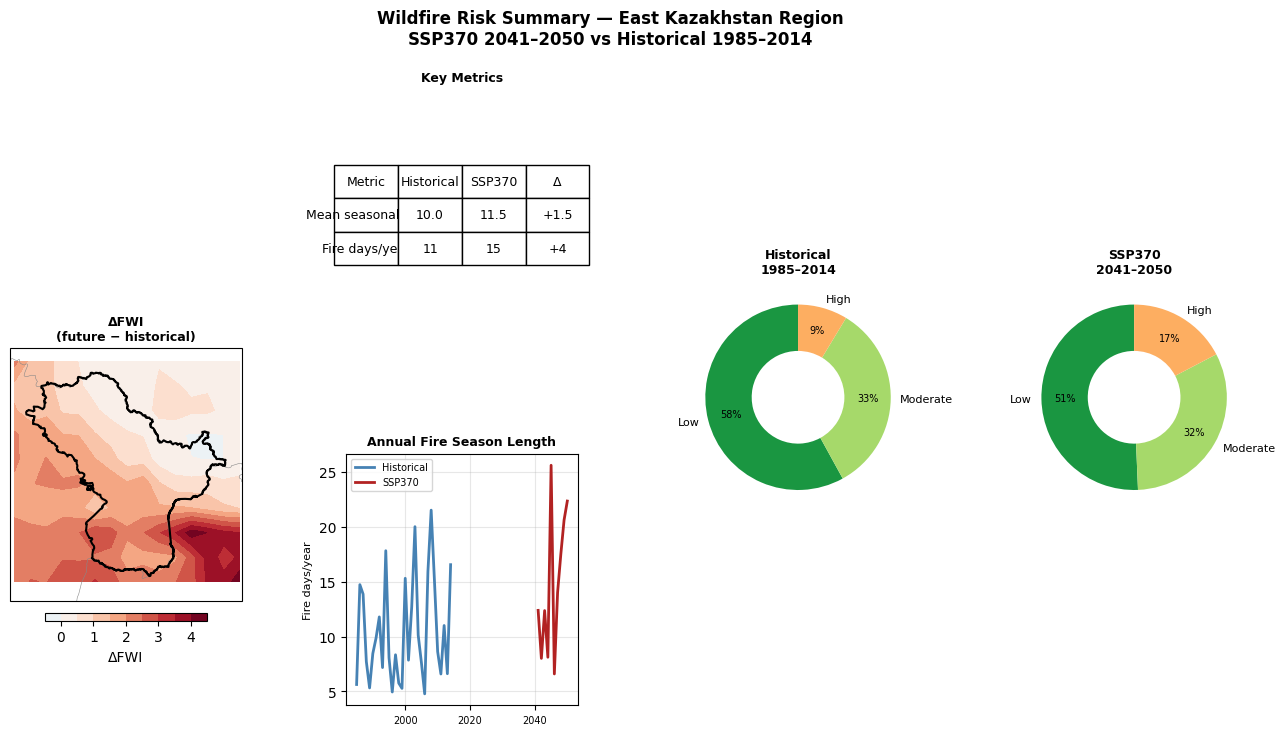

In [37]:
wts   = np.cos(np.deg2rad(hist_seas.lat))
h_reg = float(hist_seas.weighted(wts).mean(dim=['lat', 'lon', 'year', 'model']))
f_reg = float(fut_seas.weighted(wts).mean(dim=['lat', 'lon', 'year', 'model']))
h_fd  = float(hist_fday.weighted(wts).mean(dim=['lat', 'lon', 'year', 'model']))
f_fd  = float(fut_fday.weighted(wts).mean(dim=['lat', 'lon', 'year', 'model']))

h_fracs = class_fracs(hist_mean.ravel(), DANGER_BREAKS)
f_fracs = class_fracs(fut_mean.ravel(),  DANGER_BREAKS)

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.45, hspace=0.45)

# A: delta map
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())
add_kaz_boundary(ax_map)
vmax_d = max(np.nanmax(np.abs(delta_fwi)), 0.1)
cf = ax_map.contourf(lon2d, lat2d, delta_fwi, transform=ccrs.PlateCarree(),
                     cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d, levels=10)
plt.colorbar(cf, ax=ax_map, shrink=0.7, pad=0.02,
             label='ΔFWI', orientation='horizontal')
ax_map.set_title('ΔFWI\n(future − historical)', fontsize=9, fontweight='bold')

# B: key metrics table
ax_tbl = fig.add_subplot(gs[0, 1])
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=[
        ['Mean seasonal FWI', f'{h_reg:.1f}', f'{f_reg:.1f}', f'{f_reg-h_reg:+.1f}'],
        ['Fire days/year',    f'{h_fd:.0f}',  f'{f_fd:.0f}',  f'{f_fd-h_fd:+.0f}'],
    ],
    colLabels=['Metric', 'Historical', FUTURE_SCENARIO.upper(), 'Δ'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 2.0)
ax_tbl.set_title('Key Metrics', fontsize=9, fontweight='bold')

# C: fire season length time series
ax_ts = fig.add_subplot(gs[1, 1])
h_ts = hist_fday.weighted(wts).mean(dim=['lat', 'lon']).mean(dim='model').values
f_ts = fut_fday.weighted(wts).mean(dim=['lat', 'lon']).mean(dim='model').values
ax_ts.plot(hist_ds.year.values, h_ts, color='steelblue', lw=2, label='Historical')
ax_ts.plot(fut_ds.year.values,  f_ts, color='firebrick',  lw=2, label=FUTURE_SCENARIO.upper())
ax_ts.set_ylabel('Fire days/year', fontsize=8)
ax_ts.set_title('Annual Fire Season Length', fontsize=9, fontweight='bold')
ax_ts.legend(fontsize=7); ax_ts.grid(alpha=0.3)
for tick in ax_ts.get_xticklabels(): tick.set_fontsize(7)

# D & E: danger class donuts
for col, (fracs, lbl, period) in enumerate([
    (h_fracs, 'Historical',            f'{HIST_START}–{HIST_END}'),
    (f_fracs, FUTURE_SCENARIO.upper(), f'{FUTURE_START}–{FUTURE_END}'),
]):
    ax_d = fig.add_subplot(gs[:, 2 + col])
    nz   = [(f, l, c) for f, l, c in zip(fracs, DANGER_LABELS, DANGER_COLORS) if f > 0]
    if nz:
        fv, lv, cv = zip(*nz)
        wedges, texts, autotexts = ax_d.pie(
            fv, labels=lv, colors=cv, autopct='%1.0f%%',
            startangle=90, pctdistance=0.75, wedgeprops={'width': 0.5}
        )
        for t in texts:     t.set_fontsize(8)
        for t in autotexts: t.set_fontsize(7)
    ax_d.set_title(f'{lbl}\n{period}', fontsize=9, fontweight='bold')

fig.suptitle(f'Wildfire Risk Summary — {oblast_en}\n'
             f'{FUTURE_SCENARIO.upper()} {FUTURE_START}–{FUTURE_END} '
             f'vs Historical {HIST_START}–{HIST_END}',
             fontsize=12, fontweight='bold')
plt.savefig(results_dir / f'{region_id}_report_infographic.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

## Figure 8 — EFFIS danger class area chart

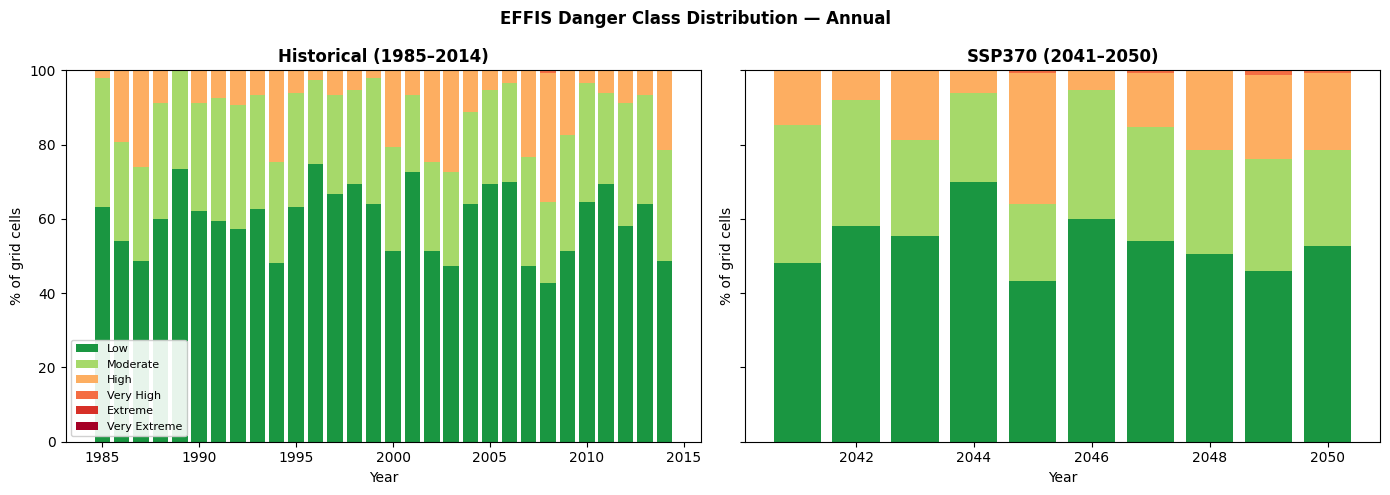

In [38]:
def yearly_class_fracs(da_3d, breaks):
    """da_3d: (year, lat, lon) numpy array."""
    n_yr, n_cls = da_3d.shape[0], len(breaks) - 1
    out = np.full((n_yr, n_cls), np.nan)
    for i in range(n_yr):
        v = da_3d[i][~np.isnan(da_3d[i])]
        if v.size:
            out[i] = [np.mean((v >= breaks[c]) & (v < breaks[c+1])) for c in range(n_cls)]
    return out

h_cls = yearly_class_fracs(hist_seas.mean(dim='model').values, DANGER_BREAKS)
f_cls = yearly_class_fracs(fut_seas.mean(dim='model').values,  DANGER_BREAKS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, cls, yrs, lbl, period in [
    (axes[0], h_cls, hist_ds.year.values, 'Historical',            f'{HIST_START}–{HIST_END}'),
    (axes[1], f_cls, fut_ds.year.values,  FUTURE_SCENARIO.upper(), f'{FUTURE_START}–{FUTURE_END}'),
]:
    bottom = np.zeros(len(yrs))
    for c, (label, color) in enumerate(zip(DANGER_LABELS, DANGER_COLORS)):
        vals = cls[:, c]; ok = ~np.isnan(vals)
        ax.bar(yrs[ok], vals[ok] * 100, bottom=bottom[ok],
               color=color, label=label, width=0.8)
        bottom[ok] += vals[ok] * 100
    ax.set_xlabel('Year'); ax.set_ylabel('% of grid cells')
    ax.set_title(f'{lbl} ({period})', fontweight='bold')
    if ax is axes[0]:
        ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

fig.suptitle('EFFIS Danger Class Distribution — Annual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_report_danger_classes.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()